In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
raw_data = pd.read_csv(url)
raw_data.shape[0]

7214

In [ ]:
raw_data.head(10)

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0
5,7,marsha miles,marsha,miles,2013-11-30,Male,1971-08-22,44,25 - 45,Other,...,1,Low,2013-11-30,2013-11-30,2013-12-01,0,1,853,0,0
6,8,edward riddle,edward,riddle,2014-02-19,Male,1974-07-23,41,25 - 45,Caucasian,...,2,Low,2014-02-19,2014-03-31,2014-04-18,14,5,40,1,1
7,9,steven stewart,steven,stewart,2013-08-30,Male,1973-02-25,43,25 - 45,Other,...,3,Low,2013-08-30,2014-05-22,2014-06-03,3,0,265,0,0
8,10,elizabeth thieme,elizabeth,thieme,2014-03-16,Female,1976-06-03,39,25 - 45,Caucasian,...,1,Low,2014-03-16,2014-03-15,2014-03-18,0,2,747,0,0
9,13,bo bradac,bo,bradac,2013-11-04,Male,1994-06-10,21,Less than 25,Caucasian,...,5,Medium,2013-11-04,2015-01-06,2015-01-07,1,0,428,1,1


In [ ]:
import numpy as np

numeric_vars  = ["age", "priors_count", "days_b_screening_arrest", "decile_score"]
datetime_vars = ["c_jail_in", "c_jail_out"]

df = raw_data[[
    "age","c_charge_degree","race","age_cat","score_text","sex",
    "priors_count","days_b_screening_arrest","decile_score",
    "is_recid","two_year_recid","c_jail_in","c_jail_out"
]]

# Filtering
df = df[(df["days_b_screening_arrest"] >= -30) & (df["days_b_screening_arrest"] <= 30)]
df = df[df["is_recid"] != -1]
df = df[df["c_charge_degree"] != "O"]
df = df[df["score_text"] != "N/A"]

# Datetime
for col in datetime_vars:
    df[col] = pd.to_datetime(df[col],errors="coerce")
for col in numeric_vars:
    df[col] = pd.to_numeric(df[col],errors="coerce")

# Derived factors
df["score_factor"] = pd.Categorical(np.where(df["score_text"] == "Low", "LowScore", "HighScore"),categories=["LowScore", "HighScore"])
df["gender_factor"] = pd.Categorical(df["sex"],categories=["Male", "Female"])
df["age_factor"] = pd.Categorical(df["age_cat"],categories=["25 - 45", "Less than 25", "Greater than 45"])
df["race_factor"] = pd.Categorical(df["race"],categories=["Caucasian", "African-American", "Hispanic", "Asian", "Native American", "Other"])
df["crime_factor"] = pd.Categorical(df["c_charge_degree"],categories=["F", "M"])

df = df.reset_index(drop=True)
df.shape[0]

6172

In [ ]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

type_map = {
    "int64": "<int>",
    "float64": "<dbl>",
    "object": "<fct>",
    "category": "<fct>",
    "datetime64[ns]": "<dttm>"}

for col in df.columns:
    dtype_str = str(df[col].dtype)
    r_type = type_map.get(dtype_str, f"<{dtype_str}>")

    vals = df[col].astype(str).tolist()[:12]
    preview = ", ".join(vals)
    print(f"$ {col:<25} {r_type:<7} {preview}...")

Rows: 6,172
Columns: 18
$ age                       <int>   69, 34, 24, 44, 41, 43, 39, 27, 23, 37, 41, 47...
$ c_charge_degree           <fct>   F, F, F, M, F, F, M, F, M, M, F, F...
$ race                      <fct>   Other, African-American, African-American, Other, Caucasian, Other, Caucasian, Caucasian, African-American, Caucasian, African-American, Caucasian...
$ age_cat                   <fct>   Greater than 45, 25 - 45, Less than 25, 25 - 45, 25 - 45, 25 - 45, 25 - 45, 25 - 45, Less than 25, 25 - 45, 25 - 45, Greater than 45...
$ score_text                <fct>   Low, Low, Low, Low, Medium, Low, Low, Low, Medium, Low, Low, Low...
$ sex                       <fct>   Male, Male, Male, Male, Male, Male, Female, Male, Male, Female, Male, Female...
$ priors_count              <int>   0, 0, 4, 0, 14, 3, 0, 0, 3, 0, 0, 1...
$ days_b_screening_arrest   <dbl>   -1.0, -1.0, -1.0, 0.0, -1.0, -1.0, -1.0, -1.0, 0.0, 0.0, -1.0, -20.0...
$ decile_score              <int>   1, 3, 4, 1, 6, 4, 1

In [ ]:
df.head(6)

,age,c_charge_degree,race,age_cat,score_text,sex,priors_count,days_b_screening_arrest,decile_score,is_recid,two_year_recid,c_jail_in,c_jail_out,score_factor,gender_factor,age_factor,race_factor,crime_factor
0,69,F,Other,Greater than 45,Low,Male,0,-1.0,1,0,0,2013-08-13 06:03:42,2013-08-14 05:41:20,LowScore,Male,Greater than 45,Other,F
1,34,F,African-American,25 - 45,Low,Male,0,-1.0,3,1,1,2013-01-26 03:45:27,2013-02-05 05:36:53,LowScore,Male,25 - 45,African-American,F
2,24,F,African-American,Less than 25,Low,Male,4,-1.0,4,1,1,2013-04-13 04:58:34,2013-04-14 07:02:04,LowScore,Male,Less than 25,African-American,F
3,44,M,Other,25 - 45,Low,Male,0,0.0,1,0,0,2013-11-30 04:50:18,2013-12-01 12:28:56,LowScore,Male,25 - 45,Other,M
4,41,F,Caucasian,25 - 45,Medium,Male,14,-1.0,6,1,1,2014-02-18 05:08:24,2014-02-24 12:18:30,HighScore,Male,25 - 45,Caucasian,F
5,43,F,Other,25 - 45,Low,Male,3,-1.0,4,0,0,2013-08-29 08:55:23,2013-08-30 08:42:13,LowScore,Male,25 - 45,Other,F


In [ ]:
df["length_of_stay"] = (df["c_jail_out"] - df["c_jail_in"]).dt.days
df["length_of_stay"].corr(df["decile_score"])

In [ ]:
df["length_of_stay"] = (
    df["c_jail_out"].dt.normalize() - df["c_jail_in"].dt.normalize()
).dt.days

corr = df[["length_of_stay", "decile_score"]].dropna().corr()
print(corr.loc["length_of_stay", "decile_score"])

0.20732969161470416


In [ ]:
print(df["age_cat"].value_counts())

age_cat
25 - 45            3532
Less than 25       1347
Greater than 45    1293
Name: count, dtype: int64


In [ ]:
print(df["race"].value_counts())

race
African-American    3175
Caucasian           2103
Hispanic             509
Other                343
Asian                 31
Native American       11
Name: count, dtype: int64


In [ ]:
print("Black defendants: %.2f%%" %            (3175 / 6172 * 100))
print("White defendants: %.2f%%" %            (2103 / 6172 * 100))
print("Hispanic defendants: %.2f%%" %         (509  / 6172 * 100))
print("Asian defendants: %.2f%%" %            (31   / 6172 * 100))
print("Native American defendants: %.2f%%" %  (11   / 6172 * 100))

Black defendants: 51.44%
White defendants: 34.07%
Hispanic defendants: 8.25%
Asian defendants: 0.50%
Native American defendants: 0.18%


In [ ]:
print(df["score_text"].value_counts())

score_text
Low       3421
Medium    1607
High      1144
Name: count, dtype: int64


In [ ]:
print(pd.crosstab(df['sex'],df['race']))

race    African-American  Asian  Caucasian  Hispanic  Native American  Other
sex                                                                         
Female               549      2        482        82                2     58
Male                2626     29       1621       427                9    285


In [ ]:
print(df["sex"].value_counts())

sex
Male      4997
Female    1175
Name: count, dtype: int64


In [ ]:
print("Men: %.2f%%" %   (4997 / 6172 * 100))
print("Women: %.2f%%" % (1175 / 6172 * 100))

Men: 80.96%
Women: 19.04%


In [ ]:
print((df['two_year_recid']==1).sum())

2809


In [ ]:
print((df['two_year_recid']==1).mean()*100)

45.51198963058976


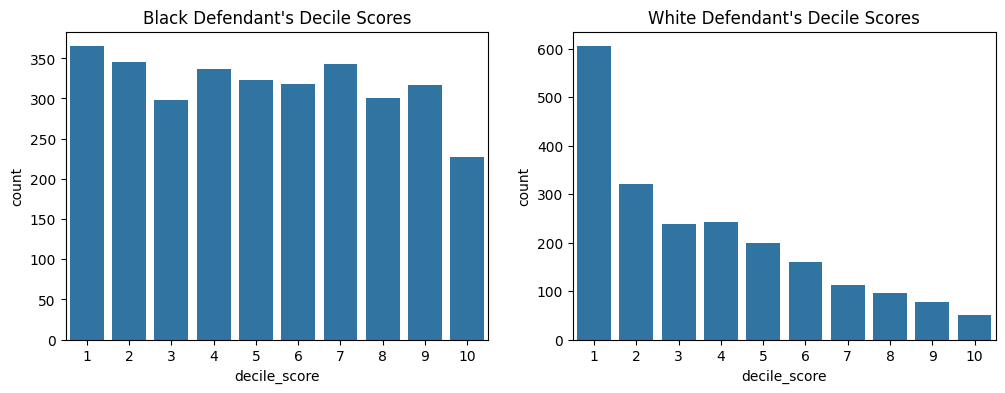

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.countplot(data=df[df["race"]=="African-American"], x="decile_score")
plt.title("Black Defendant's Decile Scores")

plt.subplot(1,2,2)
sns.countplot(data=df[df["race"]=="Caucasian"], x="decile_score")
plt.title("White Defendant's Decile Scores")

plt.show()

In [ ]:
pd.crosstab(df['decile_score'],df['race'])

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
decile_score,,,,,,
1,365,15,605,159,0,142
2,346,4,321,89,2,60
3,298,5,238,73,1,32
4,337,0,243,47,0,39
5,323,1,200,39,0,19
6,318,2,160,27,2,20
7,343,1,113,28,2,9
8,301,2,96,14,0,7
9,317,0,77,17,2,7


In [ ]:
import statsmodels.formula.api as smf
df["score_binary"] = (df["score_text"] != "Low").astype(int)

model_glm = smf.logit(
    "score_binary ~ gender_factor + age_factor + race_factor + priors_count + crime_factor + two_year_recid",
    data=df
).fit()

print(model_glm.summary2().tables[1].round(5))

Optimization terminated successfully.
         Current function value: 0.499708
         Iterations 6
                                   Coef.  Std.Err.         z    P>|z|  \
Intercept                       -1.52554   0.07851 -19.43000  0.00000   
gender_factor[T.Female]          0.22127   0.07951   2.78287  0.00539   
age_factor[T.Less than 25]       1.30839   0.07593  17.23182  0.00000   
age_factor[T.Greater than 45]   -1.35563   0.09908 -13.68211  0.00000   
race_factor[T.African-American]  0.47721   0.06935   6.88122  0.00000   
race_factor[T.Hispanic]         -0.42839   0.12813  -3.34355  0.00083   
race_factor[T.Asian]            -0.25441   0.47821  -0.53201  0.59472   
race_factor[T.Native American]   1.39421   0.76612   1.81983  0.06878   
race_factor[T.Other]            -0.82635   0.16208  -5.09838  0.00000   
crime_factor[T.M]               -0.31124   0.06655  -4.67697  0.00000   
priors_count                     0.26895   0.01110  24.22096  0.00000   
two_year_recid        

In [ ]:
control = np.exp(model_glm.params["Intercept"]) / (1 + np.exp(model_glm.params["Intercept"]))

race_coef = model_glm.params["race_factor[T.African-American]"]

print(np.exp(race_coef) / (1 - control + (control * np.exp(race_coef))))

1.452837413382345


In [ ]:
gender_coef = model_glm.params["gender_factor[T.Female]"]

print(np.exp(gender_coef) / (1 - control + (control * np.exp(gender_coef))))

1.1947946538834509


In [ ]:
age_coef = model_glm.params["age_factor[T.Less than 25]"]

print(np.exp(age_coef) / (1 - control + (control * np.exp(age_coef))))

2.496119530753956


In [ ]:
df["pred_prob"] = model_glm.predict(df)
df["pred_class"] = np.where(df["pred_prob"] >= 0.5, "Recid", "No Recid")

df["pred_class"] = pd.Categorical(df["pred_class"],categories=["No Recid", "Recid"])

In [ ]:
print("\n── Overall Confusion Matrix ──────────────────────────────────────────\n")

overall_cm = pd.crosstab(
    df["pred_class"],
    df["two_year_recid"],
    rownames=["Predicted"],
    colnames=["Actual"]
)

print(overall_cm)

# Overall metrics
TP = overall_cm.loc['Recid', 1]
TN = overall_cm.loc['No Recid', 0]
FP = overall_cm.loc['Recid', 0]
FN = overall_cm.loc['No Recid', 1]
n  = overall_cm.values.sum()

print(f"\nAccuracy  : {(TP + TN) / n:.3f}")
print(f"Precision : {TP / (TP + FP):.3f}")
print(f"Recall    : {TP / (TP + FN):.3f}")
print(f"FPR       : {FP / (FP + TN):.3f}")
print(f"FNR       : {FN / (FN + TP):.3f}")


── Overall Confusion Matrix ──────────────────────────────────────────

Actual        0     1
Predicted            
No Recid   2653   945
Recid       710  1864

Accuracy  : 0.732
Precision : 0.724
Recall    : 0.664
FPR       : 0.211
FNR       : 0.336


In [ ]:
print("\n\n── Confusion Matrix by Race ──────────────────────────────────────────\n")

temp = df.copy()
temp["actual"] = temp["two_year_recid"].astype(int)
temp["pred"]   = (temp["pred_class"] == "Recid").astype(int)

race_metrics = (
    temp.groupby("race")
    .apply(lambda g: pd.Series({
        "n": len(g),
        "TP": ((g["pred"] == 1) & (g["actual"] == 1)).sum(),
        "TN": ((g["pred"] == 0) & (g["actual"] == 0)).sum(),
        "FP": ((g["pred"] == 1) & (g["actual"] == 0)).sum(),
        "FN": ((g["pred"] == 0) & (g["actual"] == 1)).sum(),
    }))
    .reset_index()
)

race_metrics["Accuracy"]  = ((race_metrics["TP"] + race_metrics["TN"]) / race_metrics["n"]).round(3)
race_metrics["Precision"] = (race_metrics["TP"] / (race_metrics["TP"] + race_metrics["FP"])).round(3)
race_metrics["Recall"]    = (race_metrics["TP"] / (race_metrics["TP"] + race_metrics["FN"])).round(3)
race_metrics["FPR"]       = (race_metrics["FP"] / (race_metrics["FP"] + race_metrics["TN"])).round(3)
race_metrics["FNR"]       = (race_metrics["FN"] / (race_metrics["FN"] + race_metrics["TP"])).round(3)

race_metrics = race_metrics.sort_values("n", ascending=False).reset_index(drop=True)

print(race_metrics)



── Confusion Matrix by Race ──────────────────────────────────────────

               race     n    TP    TN   FP   FN  Accuracy  Precision  Recall  \
0  African-American  3175  1373   959  555  288     0.734      0.712   0.827   
1         Caucasian  2103   381  1148  133  441     0.727      0.741   0.464   
2          Hispanic   509    81   306   14  108     0.760      0.853   0.429   
3             Other   343    22   216    3  102     0.694      0.880   0.177   
4             Asian    31     2    22    1    6     0.774      0.667   0.250   
5   Native American    11     5     2    4    0     0.636      0.556   1.000   

     FPR    FNR  
0  0.367  0.173  
1  0.104  0.536  
2  0.044  0.571  
3  0.014  0.823  
4  0.043  0.750  
5  0.667  0.000  


/tmp/ipykernel_8606/573836644.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


In [ ]:
print("\n\n── FPR and FNR Disparity by Race ─────────────────────────────────────\n")

disparity = race_metrics[["race", "n", "FPR", "FNR"]].copy()

white_fpr = disparity.loc[disparity["race"] == "Caucasian", "FPR"].values[0]
white_fnr = disparity.loc[disparity["race"] == "Caucasian", "FNR"].values[0]

disparity["delta_FPR"] = (disparity["FPR"] - white_fpr).round(3)
disparity["delta_FNR"] = (disparity["FNR"] - white_fnr).round(3)

print(disparity)



── FPR and FNR Disparity by Race ─────────────────────────────────────

               race     n    FPR    FNR  delta_FPR  delta_FNR
0  African-American  3175  0.367  0.173      0.263     -0.363
1         Caucasian  2103  0.104  0.536      0.000      0.000
2          Hispanic   509  0.044  0.571     -0.060      0.035
3             Other   343  0.014  0.823     -0.090      0.287
4             Asian    31  0.043  0.750     -0.061      0.214
5   Native American    11  0.667  0.000      0.563     -0.536


**Interpretation of the Results**

The analysis of the COMPAS dataset shows several relationships between risk scores, prior offenses, age, race, and recidivism outcomes.

* The priors_count generally show a positive relationship with COMPAS risk score
and recidivism. This means that individuals with more prior offenses tend to have higher risk scores.

* Age shows a negative relationship with recidivism and risk score. Younger individuals are more likely to reoffend and have higher risk scores, while older individuals tend to have lower recidivism rates and lower risk scores.

* The analysis shows differences in score distributions across racial groups. For example, some groups may appear more frequently in higher risk categories. However, this does not necessarily prove bias by itself; it shows disparities in outcomes, which may be influenced by prior arrests, socioeconomic factors, policing patterns, or other variables included in the model.

* Jail_stay_length is not a strong predictor compared to prior offenses and age.

Overall, the main conclusion is that prior offenses and age are the strongest predictors, while other variables such as race and jail stay show weaker relationships depending on the model and filtering steps.

**Minor differences that arise due to library implementations**

Minor differences in numerical results may occur due to differences in  missing value handling, and statistical implementation across Python libraries such as pandas, numpy, and statsmodels. These differences are small and do not significantly affect the overall conclusions of the analysis.